# 06.3 — Scanpy Native UMAP Visualizations

**Purpose:** Use scanpy's `sc.pl.umap` for faceted cell-type visualization and 
marker gene expression overlay. This leverages scanpy's built-in plotting which 
supports per-cell-type highlighting, automatic coloring, and gene expression heatmaps.

Complements 06.1 (static matplotlib) and 06.2 (interactive Plotly) with scanpy's 
native UMAP panels for:
1. Per-cell-type side-by-side panels
2. Marker gene expression verification for CD8+ T cells
3. Species (mouse vs human) overlay
4. Model predictions overlaid on reference UMAP

In [1]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

RESULTS = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8")
IMPACT_OR_DIR = RESULTS / "impact_or"
CELLOT_DIR = RESULTS / "cellot"

_cellot_data = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad")
_repo_data = RESULTS / "data.h5ad"
DATA_PATH = str(_cellot_data if _cellot_data.exists() else _repo_data)

HOLDOUT = "CL:0000625"
CT_COL = "cell_type_ontology_term_id"
SOURCE, TARGET = "mouse", "human"


def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)


print(f"Data path: {DATA_PATH}")
print("Setup complete.")

Data path: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad
Setup complete.


## 1. Load Data and Compute Reference UMAP

In [2]:
full_data = anndata.read_h5ad(DATA_PATH)
print(f"Full dataset: {full_data.shape}")
print(f"Obs columns: {list(full_data.obs.columns)}")
print(f"\nCell types:")
for ct_id, n in full_data.obs[CT_COL].value_counts().items():
    label = ""
    if 'cell_type' in full_data.obs.columns:
        match = full_data.obs.loc[full_data.obs[CT_COL] == ct_id, 'cell_type']
        if len(match) > 0:
            label = f" ({match.iloc[0]})"
    print(f"  {ct_id}{label}: {n} cells")

ref = full_data.copy()
ref.X = to_dense(ref.X).astype(np.float32)

print(f"\nComputing PCA (n_comps=30) ...")
sc.pp.pca(ref, n_comps=30)

print("Computing neighbors (n_neighbors=15, n_pcs=30) ...")
sc.pp.neighbors(ref, n_pcs=30, n_neighbors=15)

print("Computing UMAP (min_dist=0.3, random_state=42) ...")
sc.tl.umap(ref, min_dist=0.3, random_state=42)

print(f"\nReference UMAP done: {ref.obsm['X_umap'].shape}")

Full dataset: (12836, 1000)
Obs columns: ['condition', 'cell_type_ontology_term_id', 'cell_type', 'tissue_ontology_term_id', 'tissue', 'donor_id']

Cell types:
  CL:0008001 (hematopoietic precursor cell): 1584 cells
  CL:0000037 (hematopoietic stem cell): 1442 cells
  CL:0002393 (intermediate monocyte): 1008 cells
  CL:0000623 (natural killer cell): 912 cells
  CL:0000893 (thymocyte): 910 cells
  CL:0000875 (non-classical monocyte): 852 cells
  CL:1000320 (large intestine goblet cell): 760 cells
  CL:0002063 (pulmonary alveolar type 2 cell): 584 cells
  CL:0002543 (vein endothelial cell): 574 cells
  CL:0002548 (fibroblast of cardiac tissue): 484 cells
  CL:0002598 (bronchial smooth muscle cell): 440 cells
  CL:0000786 (plasma cell): 410 cells
  CL:0000236 (B cell): 406 cells
  CL:0000115 (endothelial cell): 406 cells
  CL:0000625 (CD8-positive, alpha-beta T cell): 390 cells
  CL:0000767 (basophil): 286 cells
  CL:0000084 (T cell): 204 cells
  CL:0000235 (macrophage): 204 cells
  CL:00

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing UMAP (min_dist=0.3, random_state=42) ...

Reference UMAP done: (12836, 2)


## 2. All Cell Types — Overview

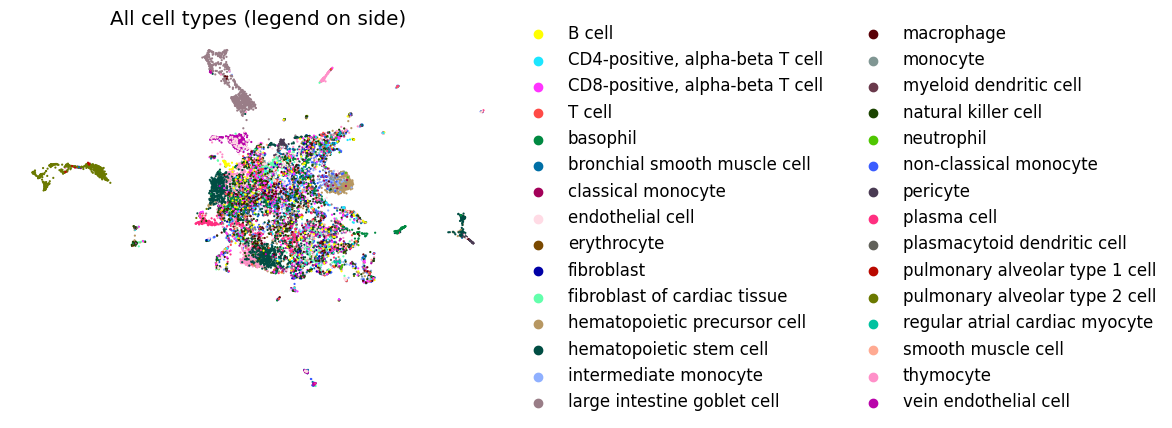

In [4]:
sc.pl.umap(ref, color='cell_type', frameon=False,
           title='All cell types (legend on side)', s=10)
plt.show()

## 3. Per-Cell-Type Side-by-Side Panels

Each cell type highlighted individually against a gray background.
This isolates the spatial distribution of each cell type.

Showing 12 cell types in panels


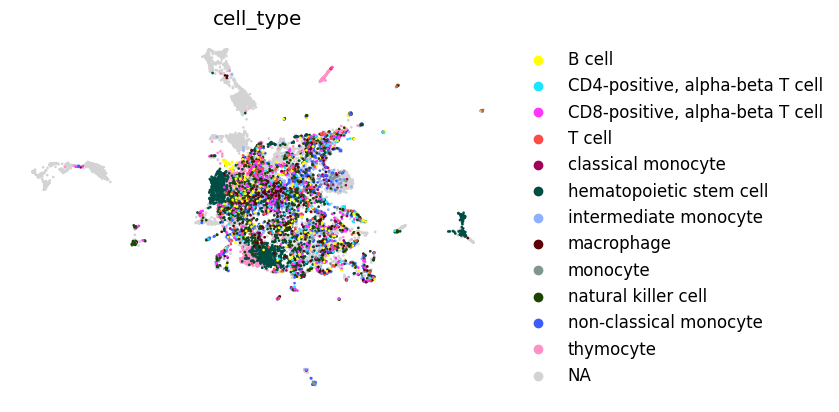

<Figure size 640x480 with 0 Axes>

In [5]:
key_types = [
    'CD8-positive, alpha-beta T cell',
    'CD4-positive, alpha-beta T cell',
    'thymocyte',
    'T cell',
    'non-classical monocyte',
    'classical monocyte',
    'intermediate monocyte',
    'monocyte',
    'natural killer cell',
    'B cell',
    'macrophage',
    'hematopoietic stem cell',
]
available = [ct for ct in key_types if ct in ref.obs['cell_type'].values]
print(f"Showing {len(available)} cell types in panels")

sc.pl.umap(ref, color='cell_type', groups=available, ncols=3,
           frameon=False, s=15)
plt.tight_layout()
plt.show()

## 4. Species Overlay (Mouse vs Human)

Shows how mouse and human cells mix in the UMAP space.
Good mixing indicates the cross-species alignment worked well.

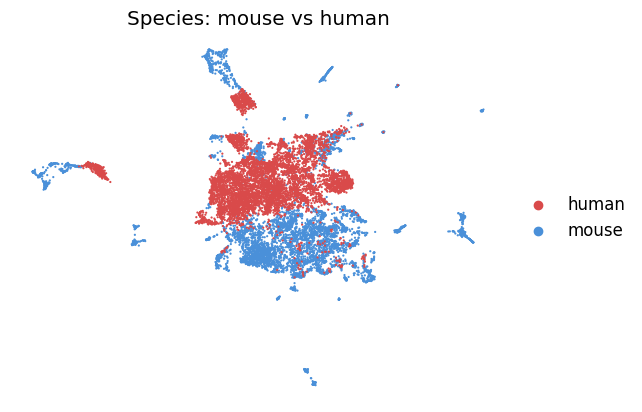

In [6]:
sc.pl.umap(ref, color='condition', frameon=False, s=10,
           palette={'mouse': '#4A90D9', 'human': '#D94A4A'},
           title='Species: mouse vs human')
plt.show()

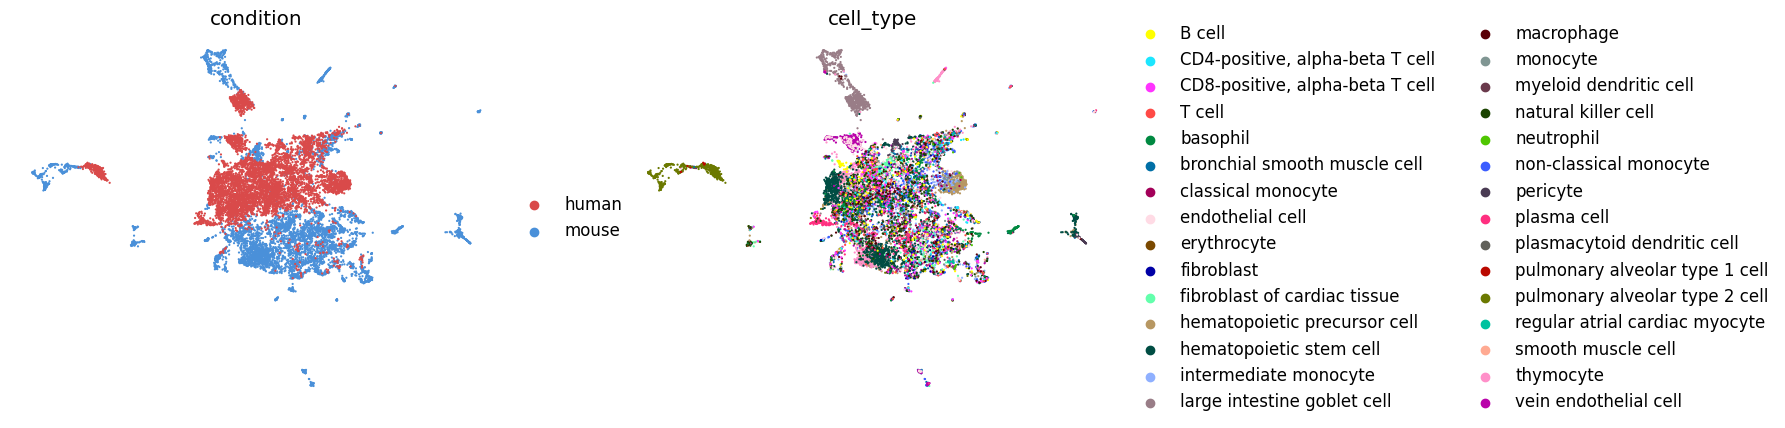

<Figure size 640x480 with 0 Axes>

In [7]:
sc.pl.umap(ref, color=['condition', 'cell_type'], frameon=False, s=10,
           ncols=2)
plt.tight_layout()
plt.show()

## 5. CD8+ Marker Gene Verification

Find the top differentially expressed genes for CD8+ T cells and overlay their
expression on the UMAP. If outlier cells in the CD8 region don't express these
markers, they may be mislabeled.

**Note:** `rank_genes_groups` uses the Wilcoxon test by default. The data should
be log-normalized (not scaled) for meaningful results.

In [8]:
sc.tl.rank_genes_groups(ref, groupby='cell_type', method='wilcoxon')

cd8_label = 'CD8-positive, alpha-beta T cell'
cd8_markers_df = sc.get.rank_genes_groups_df(ref, group=cd8_label)
print(f"Top 10 marker genes for '{cd8_label}':")
print(cd8_markers_df.head(10)[['names', 'scores', 'pvals_adj', 'logfoldchanges']].to_string())

Top 10 marker genes for 'CD8-positive, alpha-beta T cell':
             names    scores  pvals_adj  logfoldchanges
0  ENSG00000168229  3.451150   0.042939        2.042495
1  ENSG00000188001  2.145269   0.886981        1.508605
2  ENSG00000156886  1.909199   1.000000        1.674154
3  ENSG00000066855  1.799303   1.000000        1.026380
4  ENSG00000184613  1.588712   1.000000        2.622918
5  ENSG00000142765  1.292621   1.000000        0.774356
6  ENSG00000168016  1.174530   1.000000        0.588302
7  ENSG00000144290  1.045303   1.000000        2.224643
8  ENSG00000088002  0.814582   1.000000        1.186144
9  ENSG00000049247  0.709196   1.000000        1.505141


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_en

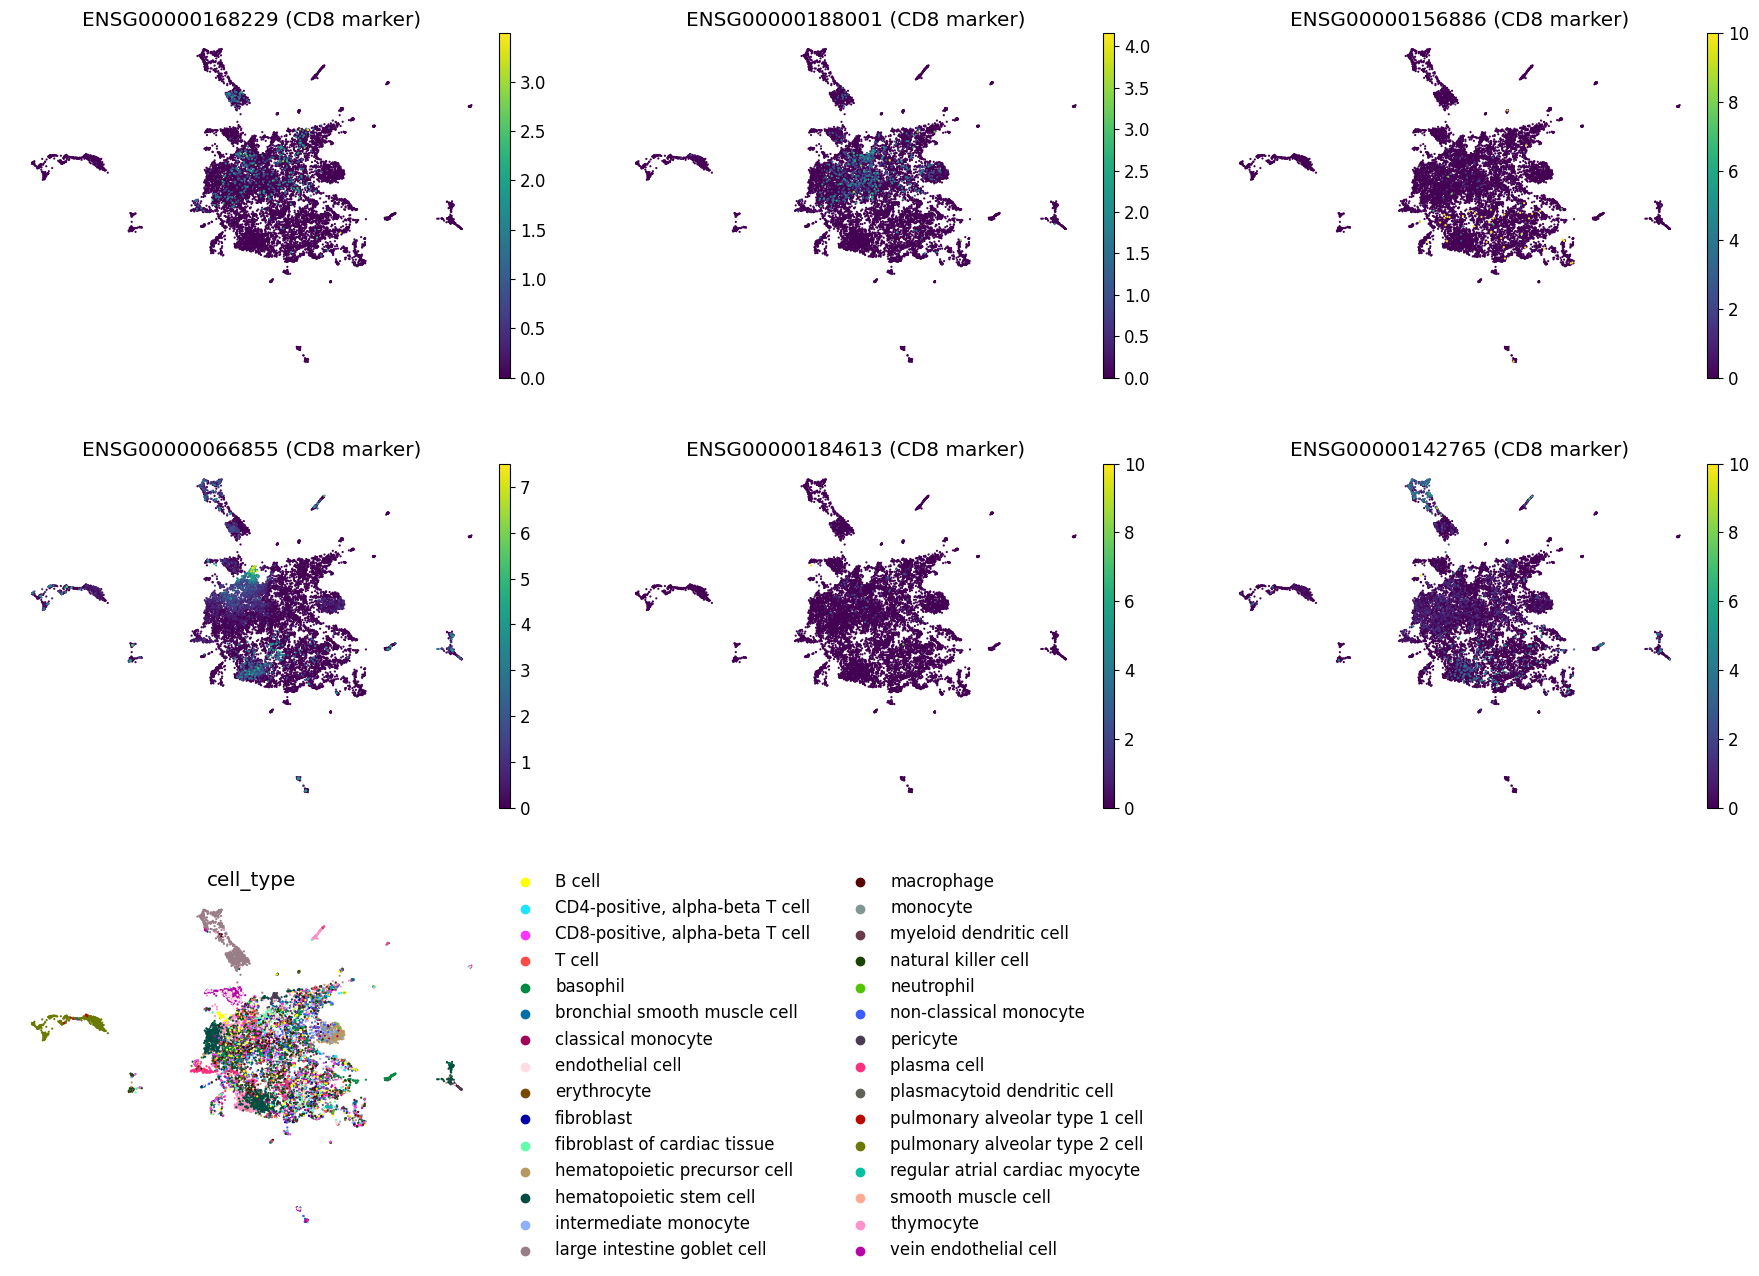

<Figure size 640x480 with 0 Axes>

In [9]:
cd8_marker_genes = cd8_markers_df.head(6)['names'].tolist()

sc.pl.umap(ref, color=[*cd8_marker_genes, 'cell_type'],
           ncols=3, frameon=False, s=10,
           title=[*[f'{g} (CD8 marker)' for g in cd8_marker_genes], 'cell_type'])
plt.tight_layout()
plt.show()

## 6. Monocyte Marker Genes

Same analysis for non-classical monocytes — useful for the monocyte holdout experiments.

Top 10 marker genes for 'non-classical monocyte':
             names    scores  pvals_adj  logfoldchanges
0  ENSG00000065833  4.284704   0.000915        0.912838
1  ENSG00000112343  3.682451   0.008250        0.859596
2  ENSG00000170909  3.243985   0.034668        1.740422
3  ENSG00000204020  2.887018   0.105111        2.870242
4  ENSG00000188001  2.742353   0.150394        1.604870
5  ENSG00000088827  2.312628   0.398906        1.898163
6  ENSG00000134755  1.853820   0.873492        0.542635
7  ENSG00000148680  1.477137   1.000000        1.682114
8  ENSG00000161896  1.438021   1.000000        3.326488
9  ENSG00000112679  1.381707   1.000000        0.773251


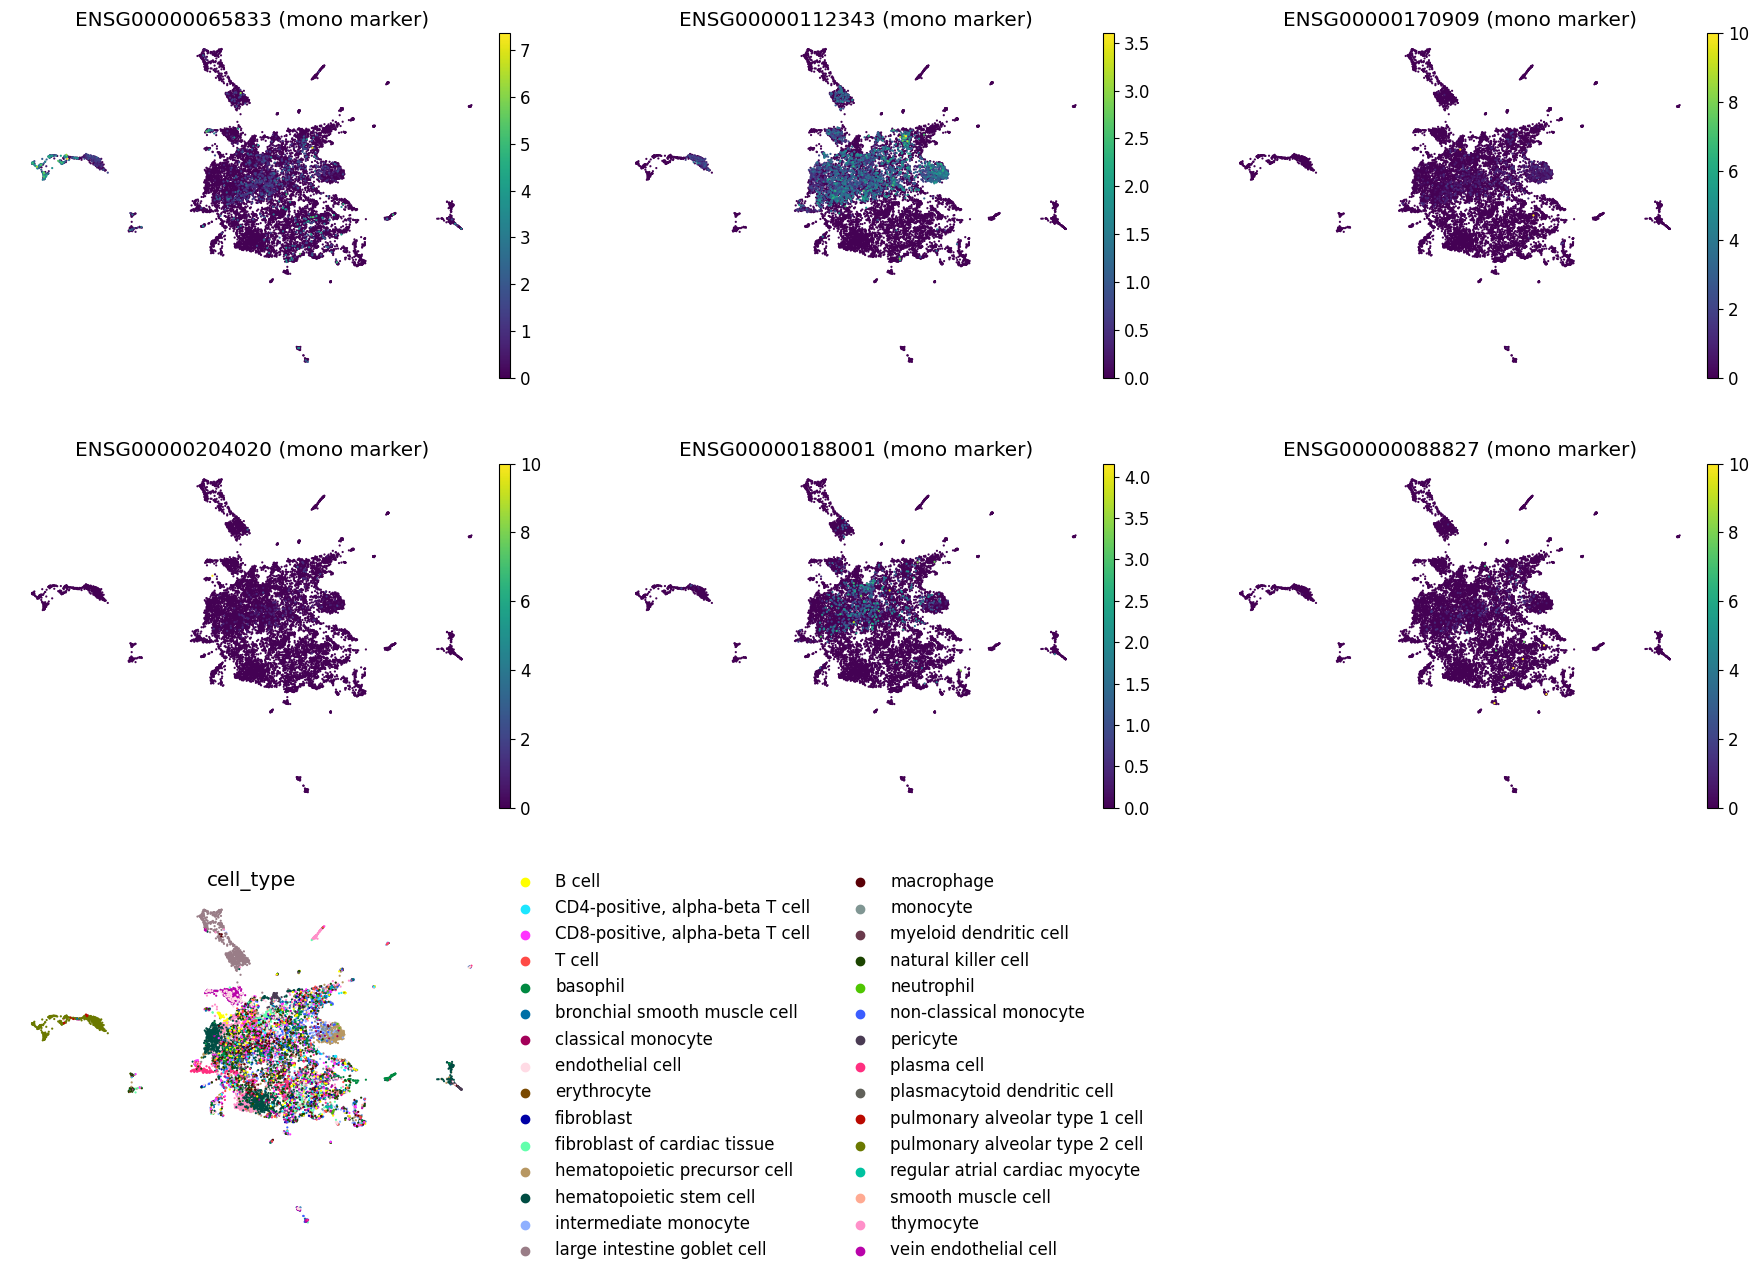

<Figure size 640x480 with 0 Axes>

In [10]:
mono_label = 'non-classical monocyte'
if mono_label in ref.obs['cell_type'].values:
    mono_markers_df = sc.get.rank_genes_groups_df(ref, group=mono_label)
    print(f"Top 10 marker genes for '{mono_label}':")
    print(mono_markers_df.head(10)[['names', 'scores', 'pvals_adj', 'logfoldchanges']].to_string())
    
    mono_marker_genes = mono_markers_df.head(6)['names'].tolist()
    
    sc.pl.umap(ref, color=[*mono_marker_genes, 'cell_type'],
               ncols=3, frameon=False, s=10,
               title=[*[f'{g} (mono marker)' for g in mono_marker_genes], 'cell_type'])
    plt.tight_layout()
    plt.show()
else:
    print(f"'{mono_label}' not found in cell_type column")

## 7. Model Predictions on Reference UMAP

Project IMPACT-OR and CellOT predictions onto the reference UMAP using kNN
in PCA space, then visualize alongside ground truth.

In [11]:
from sklearn.neighbors import NearestNeighbors

predictions = {}

imp_path = IMPACT_OR_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if imp_path.exists():
    _imp = anndata.read_h5ad(str(imp_path))
    _imp.var_names = ref.var_names.copy()
    predictions['IMPACT-OR'] = _imp
    print(f"IMPACT-OR: {_imp.shape}")

cot_path = CELLOT_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if cot_path.exists():
    _cot = anndata.read_h5ad(str(cot_path))
    _cot.var_names = ref.var_names.copy()
    predictions['CellOT'] = _cot
    print(f"CellOT: {_cot.shape}")


def project_onto_ref_umap(pred_X, ref_adata, n_neighbors=10):
    """Project cells onto reference UMAP via kNN weighted average in PCA space."""
    pcs = ref_adata.varm['PCs']
    ref_pca = ref_adata.obsm['X_pca']
    ref_umap = ref_adata.obsm['X_umap']
    
    pred_centered = pred_X - ref_adata.X.mean(axis=0)
    pred_pca = pred_centered @ pcs
    
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(ref_pca)
    dists, idxs = nn.kneighbors(pred_pca)
    
    weights = 1.0 / (dists + 1e-8)
    weights = weights / weights.sum(axis=1, keepdims=True)
    pred_umap = np.array([
        (weights[i, :, None] * ref_umap[idxs[i]]).sum(axis=0)
        for i in range(len(pred_pca))
    ])
    return pred_umap


for name, pred_adata in predictions.items():
    pred_X = to_dense(pred_adata.X).astype(np.float32)
    pred_umap = project_onto_ref_umap(pred_X, ref)
    predictions[name].obsm['X_umap'] = pred_umap
    print(f"{name}: projected {pred_adata.n_obs} cells")

IMPACT-OR: (195, 1000)
CellOT: (6223, 1000)
IMPACT-OR: projected 195 cells
CellOT: projected 6223 cells


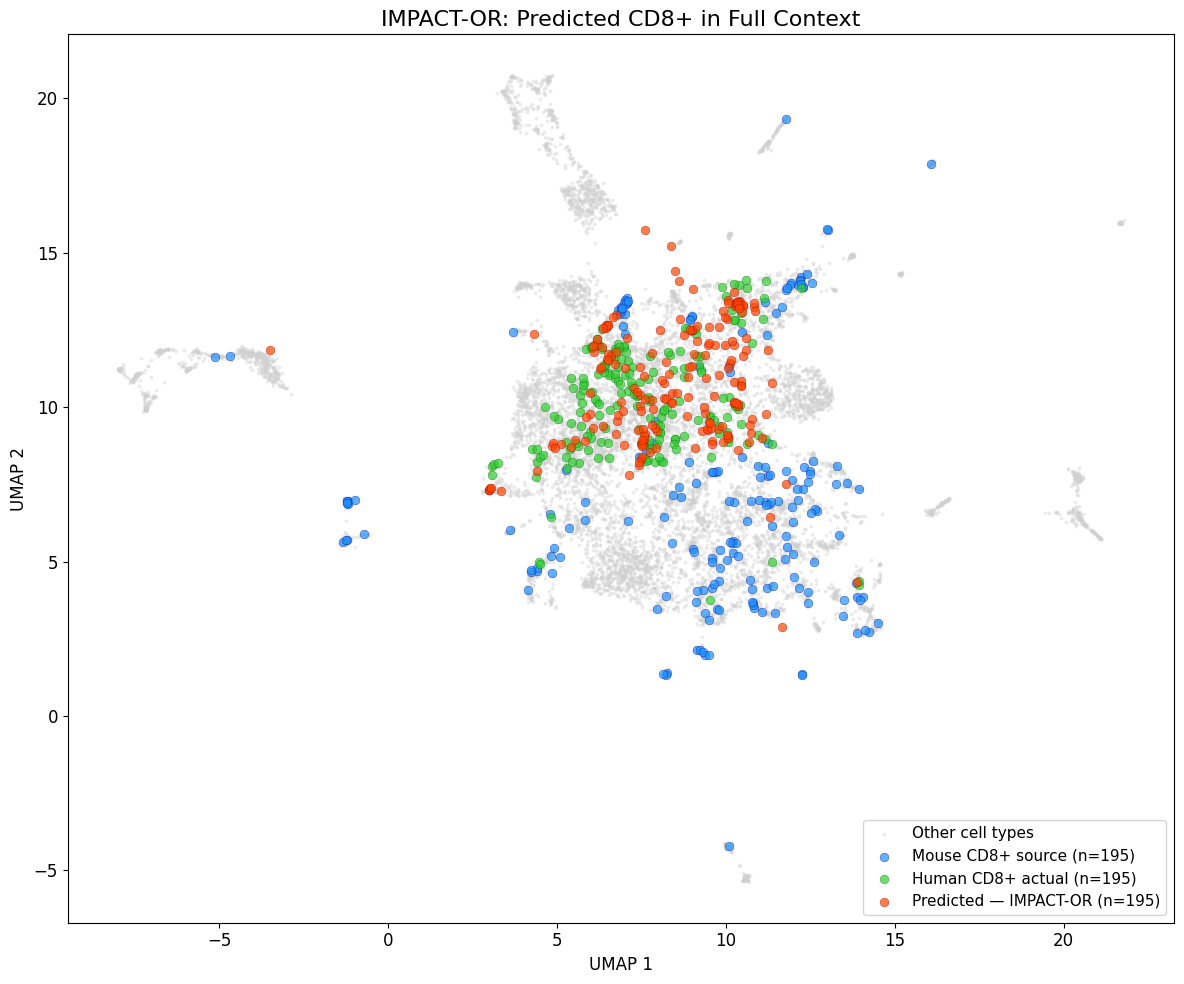

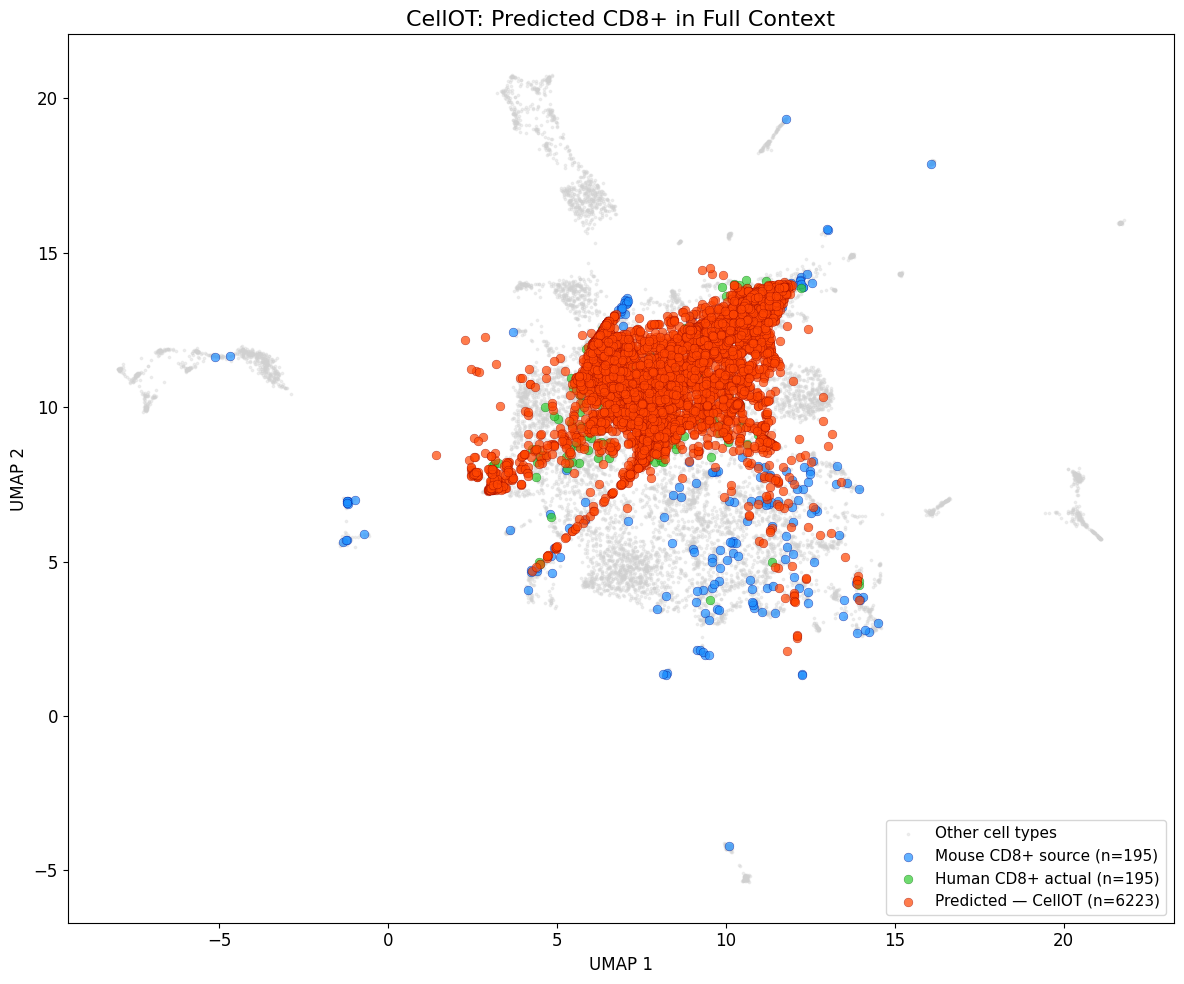

In [12]:
holdout_mask = ref.obs[CT_COL].astype(str).str.strip() == HOLDOUT
source_mask = ref.obs['condition'].astype(str).str.strip() == SOURCE
target_mask = ref.obs['condition'].astype(str).str.strip() == TARGET
src_cd8 = holdout_mask & source_mask
tgt_cd8 = holdout_mask & target_mask

for model_name, pred_adata in predictions.items():
    fig, ax = plt.subplots(figsize=(12, 10))
    
    umap_all = ref.obsm['X_umap']
    bg = ~holdout_mask
    
    ax.scatter(umap_all[bg, 0], umap_all[bg, 1],
               s=3, c='#d0d0d0', alpha=0.3, rasterized=True, label='Other cell types')
    ax.scatter(umap_all[src_cd8, 0], umap_all[src_cd8, 1],
               s=40, c='dodgerblue', alpha=0.7, edgecolors='navy', linewidths=0.3,
               label=f'Mouse CD8+ source (n={src_cd8.sum()})')
    ax.scatter(umap_all[tgt_cd8, 0], umap_all[tgt_cd8, 1],
               s=40, c='limegreen', alpha=0.7, edgecolors='darkgreen', linewidths=0.3,
               label=f'Human CD8+ actual (n={tgt_cd8.sum()})')
    
    pred_umap = pred_adata.obsm['X_umap']
    ax.scatter(pred_umap[:, 0], pred_umap[:, 1],
               s=40, c='orangered', alpha=0.7, edgecolors='darkred', linewidths=0.3,
               label=f'Predicted — {model_name} (n={pred_umap.shape[0]})')
    
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'{model_name}: Predicted CD8+ in Full Context', fontsize=16)
    ax.legend(fontsize=11, loc='lower right')
    plt.tight_layout()
    plt.show()

## Summary

This notebook provides three types of visualization:
1. **Per-cell-type panels** — each cell type highlighted individually
2. **Marker gene overlays** — CD8 and monocyte marker expression across UMAP
3. **Model prediction overlays** — IMPACT-OR and CellOT predictions in context

Use these alongside the interactive Plotly UMAP in notebook 06.2 for complete
outlier diagnosis.